In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
import numpy as np #as numerical library
import pandas as pd #for data analysis
import matplotlib.pyplot as plt #visualization
import seaborn as sns #statistical
from scipy.sparse import hstack #for scientific computing tools

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping
#from sklearn.pipeline import Pipeline

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("\nDataset Shapes")
print("Train:", train.shape)
print("Test :", test.shape)

print("\nDataset Info")
print(train.info())

print("\nDataset Description")
print(train.describe())

print("\nSample Data")
print(train.head())


Dataset Shapes
Train: (198000, 15)
Test : (102000, 14)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None

Dataset Description
  


Feature Types
Text Feature: comment
Categorical Features: ['race', 'religion', 'gender', 'disability', 'created_date']
Numeric Features: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']

Missing Values (Train)
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Missing Values (Test)
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


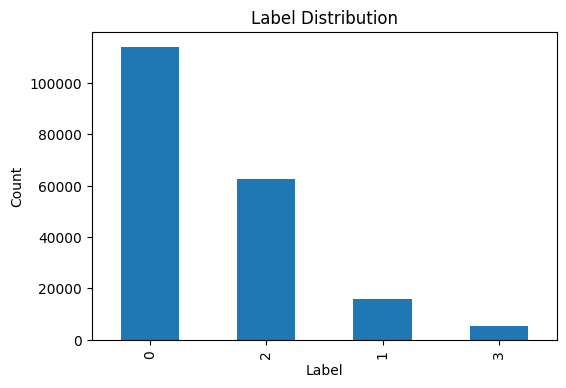

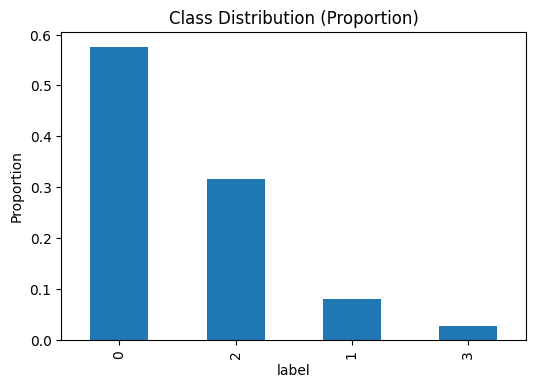

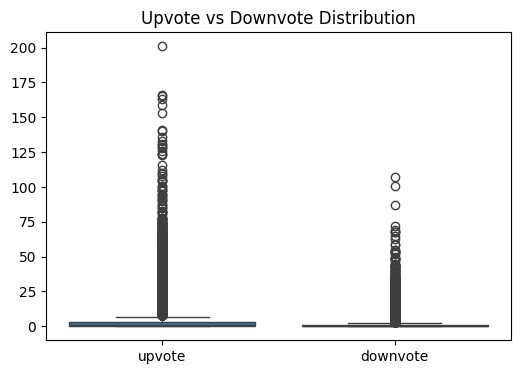


TF-IDF Feature Shape: (198000, 5000)
Final Feature Matrix Shape: (198000, 5008)

Train Shape: (158400, 5008)
Validation Shape: (39600, 5008)


In [3]:
# ============================================================
# MILESTONE 1: BASIC EDA
# ============================================================
target_column = "label" #predicting
text_column = "comment" #main text feature

print("\nFeature Types")

print("Text Feature:", text_column)

categorical_cols = ["race","religion","gender","disability","created_date"]
print("Categorical Features:", categorical_cols)

numeric_cols = train.drop(columns=[text_column,target_column] + categorical_cols).columns
print("Numeric Features:", list(numeric_cols))

print("\nMissing Values (Train)")
print(train.isnull().sum())
print("\nMissing Values (Test)")
print(test.isnull().sum())

# Fill missing categorical columns with 'unknown'
for col in ["race","religion","gender"]:
    train[col] = train[col].fillna("unknown")
    test[col] = test[col].fillna("unknown")
# Fill other missing
train = train.fillna(0)
test = test.fillna(0)

#All comments in strings 
train[text_column] = train[text_column].astype(str)
test[text_column] = test[text_column].astype(str)

#visualizing distribution
plt.figure(figsize=(6,4))
train[target_column].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
train[target_column].value_counts(normalize=True).plot(kind="bar")
plt.title("Class Distribution (Proportion)")
plt.ylabel("Proportion")
plt.show()

#visualizing engagement
if "upvote" in train.columns and "downvote" in train.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=train[["upvote","downvote"]])
    plt.title("Upvote vs Downvote Distribution")
    plt.show()


# ============================================================
# FEATURE ENGINEERING
# ============================================================

# ---------- TF-IDF TEXT FEATURES ----------
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    sublinear_tf=True,
    ngram_range=(1,2)
) 
#Converts text to numeric vectors
X_text = tfidf.fit_transform(train[text_column])
X_test_text = tfidf.transform(test[text_column])
print("\nTF-IDF Feature Shape:", X_text.shape)

#demo_pipeline = Pipeline([
#    ("tfidf", TfidfVectorizer(max_features=2000, stop_words="english")),
#    ("clf", LogisticRegression(max_iter=2000))
#])

#demo_pipeline.fit(train[text_column], y)

# ---------- NUMERIC FEATURES ----------
categorical_cols = ["race","religion","gender","disability","created_date"]
#Extract numeric columns only
X_num = train.drop(columns=[text_column, target_column] + categorical_cols)
X_test_num = test.drop(columns=[text_column] + categorical_cols)
#scales numeric features to mean=0, std=1
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_test_num_scaled = scaler.transform(X_test_num)

# ---------- COMBINE FEATURES ----------
#Combines text (5000 features) + numeric (8 features) → 5008 features total
X_full = hstack([X_text, X_num_scaled])
X_test_full = hstack([X_test_text, X_test_num_scaled])
#hstack: sparse matrix stacking, memory-efficient for TF-IDF
y = train[target_column]

print("Final Feature Matrix Shape:", X_full.shape)

# ============================================================
# TRAIN – VALIDATION SPLIT
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
) #stratify=y: ensures class distribution remains same in both splits

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

In [4]:
# ============================================================
# MILESTONE 2: LINEAR MODELS
# ============================================================
#predicts class probabilities using the logistic/sigmoid function
lr = LogisticRegression(max_iter=5000, n_jobs=-1)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_val, lr.predict(X_val))
print("Logistic Regression Accuracy:", lr_acc)
#very high, shows that TF-IDF + numeric features are informative

#trained with stochastic gradient descent
sgd = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)
sgd_acc = accuracy_score(y_val, sgd.predict(X_val))
print("SGD Accuracy:", sgd_acc)
#slightly lower, sensitive to learning rate and scaling

#Hyperparameter Tuning for SGD
param_grid = {
    "alpha":[1e-5,1e-4],
    "max_iter":[2000]
}

sgd_tuned = GridSearchCV( #tests combinations of hyperparameters to find the best one
    SGDClassifier(loss="log_loss", random_state=42),
    param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

sgd_tuned.fit(X_train, y_train)

best_sgd = sgd_tuned.best_estimator_

sgd_tuned_acc = accuracy_score(
    y_val,
    best_sgd.predict(X_val)
)

print("Best SGD Parameters:", sgd_tuned.best_params_)
print("Tuned SGD Accuracy:", sgd_tuned_acc) #no improvement over default

Logistic Regression Accuracy: 0.9031818181818182
SGD Accuracy: 0.8811363636363636
Best SGD Parameters: {'alpha': 0.0001, 'max_iter': 2000}
Tuned SGD Accuracy: 0.8811363636363636


In [5]:
# ============================================================
# MILESTONE 3: FEATURE SELECTION + SVD
# ============================================================

#Very high-dimensional for some non-linear models
minmax = MinMaxScaler() #rescales numeric features to range [0, 1]

X_num_mm = minmax.fit_transform(X_num)
X_test_num_mm = minmax.transform(X_test_num)

X_fs_full = hstack([X_text, X_num_mm])
X_test_fs_full = hstack([X_test_text, X_test_num_mm])
# feature selection and dimensionality reduction applied
print("Feature Shape Before Selection:", X_fs_full.shape)

X_train_fs_full, X_val_fs_full, y_train_fs, y_val_fs = train_test_split(
    X_fs_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

selector = SelectKBest(score_func=chi2, k=3000)
X_train_fs = selector.fit_transform(X_train_fs_full, y_train_fs)
X_val_fs = selector.transform(X_val_fs_full)
print("After SelectKBest:", X_train_fs.shape)
#Reduces irrelevant/noisy features

#reduces high-dimensional sparse matrices into dense lower-dimensional matrices
svd = TruncatedSVD(n_components=400, random_state=42)
X_train_svd = svd.fit_transform(X_train_fs)
X_val_svd = svd.transform(X_val_fs)
print("After SVD:", X_train_svd.shape)

# ---------- NAIVE BAYES ----------
nb = MultinomialNB(alpha=0.5) #ideal for text data
nb.fit(X_text[y_train.index], y_train)
nb_acc = accuracy_score(
    y_val,
    nb.predict(X_text[y_val.index])
)
print("Naive Bayes Accuracy:", nb_acc)
#lower cause NB ignores numeric features and feature correlations.

# ---------- KNN ----------
knn = KNeighborsClassifier( #predicts a sample’s label by majority vote of 7 nearest neighbors
    n_neighbors=7,
    metric="cosine",
    weights="distance"
)
knn.fit(X_train_svd, y_train_fs)
knn_acc = accuracy_score(
    y_val_fs,
    knn.predict(X_val_svd)
)
print("KNN Accuracy:", knn_acc)
#poor cause KNN struggles with high-dimensional data, even after SVD

# ---------- SVM ----------
svm = LinearSVC( #finds a hyperplane separating classes
    C=2.5,
    max_iter=5000,
    random_state=42
)
svm.fit(X_train_svd, y_train_fs)
svm_acc = accuracy_score(
    y_val_fs,
    svm.predict(X_val_svd)
)
print("SVM Accuracy:", svm_acc)
#lower cause SVD loses some discriminative information

Feature Shape Before Selection: (198000, 5008)
After SelectKBest: (158400, 3000)
After SVD: (158400, 400)
Naive Bayes Accuracy: 0.7196212121212121
KNN Accuracy: 0.633989898989899
SVM Accuracy: 0.7103282828282829


In [6]:
# ============================================================
# MILESTONE 4: ENSEMBLES + MLP
# ============================================================

rf = RandomForestClassifier( #ensemble of decision trees
    n_estimators=100,
    random_state=42,
    n_jobs=-1
) #Each tree is trained on a bootstrap sample 
  #=(random subset of data + features)

rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_val, rf.predict(X_val))
print("Random Forest Accuracy:", rf_acc)
#better than SGD and comparable to Logistic Regression

ada = AdaBoostClassifier( #trains weak learners to correct previous errors
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
) #Works best for smaller, cleaner datasets

ada.fit(X_train, y_train)
ada_acc = accuracy_score(y_val, ada.predict(X_val))
print("AdaBoost Accuracy:", ada_acc)
#lower cause struggle with high-dimensional sparse features (TF-IDF) compared to RF

stack = StackingClassifier( #combines multiple base learners, uses a meta-learner to combine predictions
    estimators=[
        ("lr", LogisticRegression(max_iter=3000)),
        ("sgd", SGDClassifier(loss="log_loss", alpha=1e-4, random_state=42)),
        ("svm", LinearSVC(C=1.5))
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    n_jobs=-1
)

stack.fit(X_train, y_train)
stack_acc = accuracy_score(y_val, stack.predict(X_val))
print("Stacking Accuracy:", stack_acc)
#improvement cause combining models leverages their strengths

mlp = MLPClassifier( #simple feedforward neural network
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    max_iter=200,
    early_stopping=True, #stops training if validation accuracy stops improving, avoids overfitting
    random_state=42
) #can capture non-linear interactions between numeric + text features

mlp.fit(X_train, y_train)
mlp_acc = accuracy_score(y_val, mlp.predict(X_val))
print("MLP Accuracy:", mlp_acc)
#Comparable to Random Forest and stacking

Random Forest Accuracy: 0.9068686868686868
AdaBoost Accuracy: 0.8628535353535354
Stacking Accuracy: 0.9084848484848485
MLP Accuracy: 0.906489898989899


In [7]:
# ============================================================
# MILESTONE 5: ADVANCED FEATURES + LIGHTGBM
# ============================================================
# Engagement & length features
train["engagement_score"] = train["upvote"] - train["downvote"]
test["engagement_score"] = test["upvote"] - test["downvote"]

train["engagement_ratio"] = train["upvote"] / (train["downvote"] + 1)
test["engagement_ratio"] = test["upvote"] / (test["downvote"] + 1)

train["comment_length"] = train["comment"].apply(len)
test["comment_length"] = test["comment"].apply(len)

train["word_count"] = train["comment"].apply(lambda x: len(x.split()))
test["word_count"] = test["comment"].apply(lambda x: len(x.split()))

train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

train["hour"] = train["created_date"].dt.hour
train["dayofweek"] = train["created_date"].dt.dayofweek

test["hour"] = test["created_date"].dt.hour
test["dayofweek"] = test["created_date"].dt.dayofweek

drop_cols = ["comment","label","created_date"]
X_num_m5 = train.drop(columns=drop_cols)
X_test_num_m5 = test.drop(columns=["comment","created_date"])

#One-hot encode categorical columns
X_num_m5 = pd.get_dummies(X_num_m5, drop_first=True)
X_test_num_m5 = pd.get_dummies(X_test_num_m5, drop_first=True)
X_test_num_m5 = X_test_num_m5.reindex(columns=X_num_m5.columns, fill_value=0)

#Scale numeric features: important for LightGBM to have normalized inputs
scaler_m5 = StandardScaler()
X_num_m5_scaled = scaler_m5.fit_transform(X_num_m5)
X_test_num_m5_scaled = scaler_m5.transform(X_test_num_m5)

# TF-IDF
tfidf_m5 = TfidfVectorizer( #captures important words/phrases
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    sublinear_tf=True
)
X_text_m5 = tfidf_m5.fit_transform(train["comment"])
X_test_text_m5 = tfidf_m5.transform(test["comment"])

X_full_m5 = hstack([X_text_m5, X_num_m5_scaled]).tocsr()
#hstack → combine sparse TF-IDF matrix with scaled numeric features.
#tocsr() → ensures efficient sparse format for LightGBM.
X_test_full_m5 = hstack([X_test_text_m5, X_test_num_m5_scaled]).tocsr()
y_m5 = train["label"]
print("New Feature Matrix Shape:", X_full_m5.shape)
#splitting
X_train_m5, X_val_m5, y_train_m5, y_val_m5 = train_test_split(
    X_full_m5, y_m5,
    test_size=0.2,
    random_state=42,
    stratify=y_m5
)

# LightGBM tuned
lgb = LGBMClassifier(
    n_estimators=800,          
    learning_rate=0.04,        
    num_leaves=112,            
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

lgb.fit(
    X_train_m5,
    y_train_m5,
    eval_set=[(X_val_m5, y_val_m5)],
    eval_metric="multi_logloss",
    callbacks=[early_stopping(50)]
)
lgb_val_acc = accuracy_score(y_val_m5, lgb.predict(X_val_m5))
print("LightGBM Validation Accuracy:", lgb_val_acc)
#best, shows advanced features + LightGBM significantly improve performance

New Feature Matrix Shape: (198000, 5034)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.684489 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 617313
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5034
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[236]	valid_0's multi_logloss: 0.259955


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Validation Accuracy: 0.9140151515151516


In [8]:
# ============================================================
# AUTO SELECT BEST MODEL
# ============================================================
model_scores = { #validation accuracy for every model trained
    "Logistic Regression":lr_acc,
    "SGD":sgd_acc,
    "Tuned SGD":sgd_tuned_acc,
    "Naive Bayes":nb_acc,
    "KNN":knn_acc,
    "SVM":svm_acc,
    "Random Forest":rf_acc,
    "AdaBoost":ada_acc,
    "Stacking":stack_acc,
    "MLP":mlp_acc,
    "LightGBM":lgb_val_acc
}
best_model_name = max(model_scores, key=model_scores.get)
print("\nBest Model Based on Validation Accuracy:", best_model_name)
print("Best Validation Accuracy:", model_scores[best_model_name])

# ============================================================
# AUTOMATIC PERFORMANCE ANALYSIS 
# ============================================================
# ---------- Milestone wise model grouping ----------
milestone_results = {
    "Milestone 2 (Linear Models)": {
        "Logistic Regression": lr_acc,
        "SGD": sgd_acc,
        "Tuned SGD": sgd_tuned_acc
    },
    "Milestone 3 (Feature Selection + SVD)": {
        "Naive Bayes": nb_acc,
        "KNN": knn_acc,
        "SVM": svm_acc
    },
    "Milestone 4 (Ensembles + Neural Network)": {
        "Random Forest": rf_acc,
        "AdaBoost": ada_acc,
        "Stacking": stack_acc,
        "MLP": mlp_acc
    },
    "Milestone 5 (Advanced Features + LightGBM)": {
        "LightGBM": lgb_val_acc
    }
}

milestone_best = {}

# ---------- Identify best model per milestone ----------
for milestone, models in milestone_results.items():

    best_model = max(models, key=models.get)
    best_score = models[best_model]

    milestone_best[milestone] = best_score

    print(f"\n{milestone}")
    print("Best Model:", best_model)
    print("Validation Accuracy:", best_score)

# ---------- Overall ranking ----------
sorted_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)

for rank,(model,score) in enumerate(sorted_models[:3], start=1):
    print(f"{rank}. {model}  |  Accuracy: {score:.4f}")

# ---------- Milestone improvement analysis ----------

milestone_list = list(milestone_best.keys())
scores_list = list(milestone_best.values())

for i in range(len(milestone_list)):
    
    print(milestone_list[i], "Best Accuracy:", round(scores_list[i],4))

    if i > 0:
        improvement = scores_list[i] - scores_list[i-1]

        if improvement > 0:
            print("Improvement from previous milestone:", round(improvement,4))
        else:
            print("Performance change:", round(improvement,4))

# ---------- Feature engineering impact ----------

if lgb_val_acc > max(lr_acc, sgd_acc, rf_acc):
    print("Advanced engineered features improved model performance.")
else:
    print("Text features remain the strongest signal for prediction.")



# ============================================================
# RETRAIN BEST MODEL
# ============================================================
#retrain it on all training data and predict on the test set
if best_model_name == "LightGBM":
    best_model = lgb
    
    best_iter = lgb.best_iteration_ if lgb.best_iteration_ else 600
    
    best_model.set_params(
        n_estimators=best_iter
    )
    
    best_model.fit(X_full_m5, y_m5)
    
    final_test_predictions = best_model.predict(X_test_full_m5)

elif best_model_name == "Naive Bayes":
    best_model = nb
    best_model.fit(X_text, y)
    final_test_predictions = best_model.predict(X_test_text)

elif best_model_name in ["KNN","SVM"]:
    best_model = knn if best_model_name == "KNN" else svm
    best_model.fit(X_train_svd, y_train_fs)
    X_test_fs = selector.transform(X_test_fs_full)
    X_test_svd = svd.transform(X_test_fs)
    final_test_predictions = best_model.predict(X_test_svd)

else:
    best_model = {
        "Logistic Regression":lr,
        "SGD":sgd,
        "Tuned SGD":best_sgd,
        "Random Forest":rf,
        "AdaBoost":ada,
        "Stacking":stack,
        "MLP":mlp
    }[best_model_name]
    best_model.fit(X_full, y)
    final_test_predictions = best_model.predict(X_test_full)


Best Model Based on Validation Accuracy: LightGBM
Best Validation Accuracy: 0.9140151515151516

Milestone 2 (Linear Models)
Best Model: Logistic Regression
Validation Accuracy: 0.9031818181818182

Milestone 3 (Feature Selection + SVD)
Best Model: Naive Bayes
Validation Accuracy: 0.7196212121212121

Milestone 4 (Ensembles + Neural Network)
Best Model: Stacking
Validation Accuracy: 0.9084848484848485

Milestone 5 (Advanced Features + LightGBM)
Best Model: LightGBM
Validation Accuracy: 0.9140151515151516
1. LightGBM  |  Accuracy: 0.9140
2. Stacking  |  Accuracy: 0.9085
3. Random Forest  |  Accuracy: 0.9069
Milestone 2 (Linear Models) Best Accuracy: 0.9032
Milestone 3 (Feature Selection + SVD) Best Accuracy: 0.7196
Performance change: -0.1836
Milestone 4 (Ensembles + Neural Network) Best Accuracy: 0.9085
Improvement from previous milestone: 0.1889
Milestone 5 (Advanced Features + LightGBM) Best Accuracy: 0.914
Improvement from previous milestone: 0.0055
Advanced engineered features improv

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# ============================================================
# CREATE SUBMISSION
# ============================================================
submission = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/Sample.csv"
)
submission["label"] = final_test_predictions
submission.to_csv("submission.csv", index=False)

print("\nFinal submission.csv created using:", best_model_name)
print(submission.head())


Final submission.csv created using: LightGBM
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
